# Import from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Records and Metadata Samples

In [ ]:
import zipfile, pandas as pd

# Unzip corpus.csv.zip
with zipfile.ZipFile('/content/drive/MyDrive/IRMA/corpus.csv.zip', 'r') as z:
    z.extractall('/content/IRMA/')

# Load the corpus
df = pd.read_csv('/content/IRMA/corpus.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head(2))

Mounted at /content/drive
(634932, 10)
['Unnamed: 0', 'doc_id', 'date', 'website', 'title', 'txt', 'URL', 'WC', 'KW', 'tfidf10']
   Unnamed: 0 doc_id        date           website  \
0           1     D1  2022-05-13         website31   
1      546112    D10  2015-03-13  scenarieconomici   

                                               title  \
0                                                NaN   
1  EDIZIONE STRAORDINARIA: LA GERMANIA, ANZICHE’ ...   

                                                 txt  \
0                                                NaN   
1  Proprio così!  Oamai è ampiamente noto il fatt...   

                                                 URL   WC        KW  \
0                                                NaN  576      cisl   
1  https://scenarieconomici.it/edizione-straordin...  180  eurozona   

                                             tfidf10  
0  cisl, azienda, distretto, gas, fermare, idroge...  
1  eurozona, alemanno, europa, deflazione, sud

In [ ]:
# Remove rows without text
df = df.dropna(subset=['txt']).reset_index(drop=True)

# Load website descriptions for the labels
websites = pd.read_csv('/content/drive/MyDrive/IRMA/website_description.csv')
print(websites.columns.tolist())
print(websites.head())

['website', 'Ndoc', 'WC_mean', 'WC_sd', 'WC_min', 'WC_max', 'DATE_min', 'DATE_max', 'type_of_news', 'Monthly_Visits', 'Visit_Duration', 'Bounce_Rate', 'Pages_per_Visit', 'Traffic_Direct', 'Traffic_Referrals', 'Traffic_Search', 'Traffic_Social', 'Social_Linkedin', 'Social_VKontakte', 'Social_Others', 'Social_Telegram_Webapp', 'Social_Youtube', 'Social_Twitter', 'Social_Facebook', 'credibility']
             website   Ndoc      WC_mean        WC_sd  WC_min  WC_max  \
0           website1   6468   187.627002    83.565686     101    1014   
1           website2   4242  1125.968961  1029.656006     101    9833   
2           website3   3344   444.312064   162.237671     115    3909   
3  comedonchisciotte  23773   401.911469   159.110861     101    2721   
4           website5  13581   260.414577   242.224639     101    4520   

     DATE_min    DATE_max                   type_of_news  Monthly_Visits  ...  \
0  2022-02-10  2022-09-06                            NaN         49500.0  ...   
1 

# Real News Datasets Saving

In [ ]:
from datasets import load_dataset
import pandas as pd

real_articles = []

# Source 1: IlPost (ARTeLab)
try:
    ds2 = load_dataset("ARTeLab/ilpost", split="train")
    for r in ds2:
        text = r.get('source', '')
        if len(text) > 200:
            real_articles.append({
                'input_text': text.strip(),
                'label': 0,
                'website': 'ilpost.it',
                'date': ''
            })
    print(f"IlPost: {len(real_articles)} articles")
except Exception as e:
    print(f"IlPost: {e}")

# Source 2: Fanpage (ARTeLab)
before = len(real_articles)
try:
    ds3 = load_dataset("ARTeLab/fanpage", split="train")
    for r in ds3:
        text = r.get('source', '')
        if len(text) > 200:
            real_articles.append({
                'input_text': text.strip(),
                'label': 0,
                'website': 'fanpage.it',
                'date': ''
            })
    print(f"Fanpage: {len(real_articles) - before} articles")
except Exception as e:
    print(f"Fanpage: {e}")

# Save
df_real = pd.DataFrame(real_articles)
df_real['credibility'] = 1.0
df_real.to_parquet('/content/drive/MyDrive/IRMA/real_news_combined.parquet', index=False)

print(f"{len(df_real)} articles saved")
print(df_real['website'].value_counts())
print(df_real['input_text'].str.len().describe())

IlPost: 34749 articles
Fanpage: 67391 articles
102140 articles saved
website
fanpage.it    67391
ilpost.it     34749
Name: count, dtype: int64
count    102140.000000
mean       1630.386107
std        1064.516398
min         201.000000
25%         976.000000
50%        1371.000000
75%        1931.000000
max       27019.000000
Name: input_text, dtype: float64


# Real News Extraction (Fixed Dates & Labels)

In [ ]:
!pip install matplotlib datasets pandas
from datasets import load_dataset
import pandas as pd
import re
from datetime import datetime

output_parquet_path = '/content/drive/MyDrive/IRMA/real_news_combined_v2.parquet'
sources = [
    {"repo": "ARTeLab/ilpost", "website": "ilpost.it"},
    {"repo": "ARTeLab/fanpage", "website": "fanpage.it"}
]

month_map = {
    'gennaio': 1, 'febbraio': 2, 'marzo': 3, 'aprile': 4,
    'maggio': 5, 'giugno': 6, 'luglio': 7, 'agosto': 8,
    'settembre': 9, 'ottobre': 10, 'novembre': 11, 'dicembre': 12
}
months_pattern = "|".join(month_map.keys())
full_date_regex = re.compile(rf"\b([1-9]|[12][0-9]|3[01])\s+({months_pattern})\s+(20[0-2]\d)\b", re.IGNORECASE)

print("Extracting all real news and parsing edge-dates where available...")
real_articles = []

for source in sources:
    repo = source["repo"]
    website = source["website"]

    try:
        print(f"Scanning {repo}...")
        ds = load_dataset(repo, split="train+validation+test")

        for r in ds:
            text = r.get('source', '')
            clean_text = text.strip()
            if not clean_text:
                continue

            words = clean_text.split()
            target_text = clean_text if len(words) <= 20 else f"{' '.join(words[:10])} {' '.join(words[-10:])}"

            # Default year to None
            year = None

            # Try to find the year in the edges
            matches = full_date_regex.findall(target_text)
            if matches:
                try:
                    year = int(matches[0][2])
                except ValueError:
                    pass # Leave year as None if the date is invalid

            # Save the article unconditionally
            real_articles.append({
                'input_text': clean_text,
                'label': 0,           # REAL NEWS
                'credibility': 1.0,   # HIGH CREDIBILITY
                'website': website,
                'year': year          # Will be the integer year, or None if no date was found
            })

    except Exception as e:
        print(f"Error loading {repo}: {e}")

df_real = pd.DataFrame(real_articles)
df_real.to_parquet(output_parquet_path, index=False)
print(f"Successfully saved {len(df_real)} Real News articles to {output_parquet_path}")

Extracting all real news and parsing edge-dates where available...
Scanning ARTeLab/ilpost...
Scanning ARTeLab/fanpage...
Successfully saved 128366 Real News articles to /content/drive/MyDrive/IRMA/real_news_combined_v2.parquet


# IRMA Fake News Clean-up (Fixed Labels)

In [ ]:
import zipfile
import pandas as pd

zip_path = '/content/drive/MyDrive/IRMA/corpus.csv.zip'
csv_extract_dir = '/content/IRMA/'
csv_file_path = '/content/IRMA/corpus.csv'
output_parquet_path = '/content/drive/MyDrive/IRMA/irma_cleaned_v2.parquet'

print("Extracting IRMA corpus...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(csv_extract_dir)

print("Loading and cleaning data...")
df = pd.read_csv(csv_file_path, low_memory=False)
df = df.dropna(subset=['txt', 'date']).copy()

# Parse dates and drop failures
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df = df.dropna(subset=['date_parsed'])

# Extract the year directly into a column
df['year'] = df['date_parsed'].dt.year

print("Formatting columns and assigning Fake News labels...")
df = df.rename(columns={'txt': 'input_text'})
df['label'] = 1          # FAKE NEWS
df['credibility'] = 0.0  # LOW CREDIBILITY

# Keep only the necessary columns to save space
df_clean = df[['input_text', 'label', 'credibility', 'website', 'year']]

df_clean.to_parquet(output_parquet_path, index=False)
print(f"Successfully saved {len(df_clean)} Fake News articles to {output_parquet_path}")

Extracting IRMA corpus...
Loading and cleaning data...
Formatting columns and assigning Fake News labels...
Successfully saved 268561 Fake News articles to /content/drive/MyDrive/IRMA/irma_cleaned_v2.parquet


# The Stratified Balancer (Year-by-Year)

In [ ]:
import pandas as pd

# Paths to the cleaned datasets
path_fake = '/content/drive/MyDrive/IRMA/irma_cleaned_v2.parquet'
path_real = '/content/drive/MyDrive/IRMA/real_news_combined_v2.parquet'

print("Loading datasets...")
df_fake = pd.read_parquet(path_fake)
df_real = pd.read_parquet(path_real)

# Ensure indices are unique for safe dropping later
df_fake = df_fake.reset_index(drop=True)

total_target_size = len(df_real)
print(f"Target Dimension: {total_target_size}.")

print("\nFiltering IRMA to the 2011-2022 window...")
df_fake = df_fake.dropna(subset=['year'])
df_fake = df_fake[(df_fake['year'] >= 2011) & (df_fake['year'] <= 2022)]
df_fake = df_fake.reset_index(drop=True)

print("\nCalculating the temporal distribution from the Real News...")
df_real_dated = df_real.dropna(subset=['year'])
df_real_dated = df_real_dated[(df_real_dated['year'] >= 2011) & (df_real_dated['year'] <= 2022)]

year_proportions = df_real_dated['year'].value_counts(normalize=True)

print("Target Distribution Shape for IRMA:")
for year, prop in year_proportions.items():
    print(f"{int(year)}: {prop:.2%}")

print("\nSampling IRMA to match proportions and total volume...")
fake_sampled_list = []

for year, prop in year_proportions.items():
    # Project the percentage onto the TOTAL desired size
    target_count = int(prop * total_target_size)

    fake_year_subset = df_fake[df_fake['year'] == year]
    actual_sample = min(target_count, len(fake_year_subset))

    if actual_sample > 0:
        fake_sampled_list.append(fake_year_subset.sample(n=actual_sample, random_state=42))

df_fake_matched = pd.concat(fake_sampled_list)

print("\nResolving rounding differences/shortfalls...")
shortfall = total_target_size - len(df_fake_matched)
shortfall = max(0, shortfall) # Ensure it doesn't go negative

if shortfall > 0:
    # Drop already used articles to avoid duplicates
    df_fake_remaining = df_fake.drop(df_fake_matched.index)

    # Sample the exact shortfall
    df_fake_fill = df_fake_remaining.sample(n=shortfall, random_state=42)
    df_fake_final = pd.concat([df_fake_matched, df_fake_fill])
else:
    # If rounding caused us to go over, trim exactly to size
    df_fake_final = df_fake_matched.sample(n=total_target_size, random_state=42)

print("\nCreating Final Master Dataset...")
# Combine Real and Fake, shuffle (frac=1), and reset index
df_final = pd.concat([df_real, df_fake_final]).sample(frac=1, random_state=42).reset_index(drop=True)

path_final_parquet = '/content/drive/MyDrive/IRMA/final_master_dataset.parquet'
path_final_csv = '/content/drive/MyDrive/IRMA/final_master_dataset.csv'

df_final.to_parquet(path_final_parquet, index=False)
df_final.to_csv(path_final_csv, index=False)

print("\n" + "="*50)
print("FINAL IRMA DIAGNOSTICS & BALANCING REPORT")
print("="*50)
print(f"Total Dataset Size: {len(df_final)}")
print(f"Class Balance:")
print(df_final['label'].value_counts().to_string())
print("-" * 30)
print(f"IRMA Base Proportional Samples: {len(df_fake_matched)}")
print(f"IRMA Shortfall Articles Added:  {shortfall}")
print("-" * 30)
print("Final count of IRMA articles saved per year (Base + Shortfall):")
final_yearly_counts = df_fake_final['year'].value_counts().sort_index()
for year, count in final_yearly_counts.items():
    print(f"{int(year)}: {count}")
print("="*50)
print(f"\nFiles saved successfully to:\n - {path_final_parquet}\n - {path_final_csv}")

Loading datasets...
Target Dimension: 128366.

Filtering IRMA to the 2011-2022 window...

Calculating the temporal distribution from the Real News...
Target Distribution Shape for IRMA:
2021: 17.26%
2015: 12.51%
2020: 12.38%
2012: 10.55%
2014: 9.77%
2013: 9.19%
2016: 8.86%
2019: 6.32%
2018: 4.63%
2011: 4.17%
2017: 3.91%
2022: 0.46%

Sampling IRMA to match proportions and total volume...

Resolving rounding differences/shortfalls...

Creating Final Master Dataset...

FINAL IRMA DIAGNOSTICS & BALANCING REPORT
Total Dataset Size: 256732
Class Balance:
label
1    128366
0    128366
------------------------------
IRMA Base Proportional Samples: 91101
IRMA Shortfall Articles Added:  37265
------------------------------
Final count of IRMA articles saved per year (Base + Shortfall):
2011: 2655
2012: 2374
2013: 3453
2014: 5057
2015: 8491
2016: 11457
2017: 7889
2018: 10471
2019: 16118
2020: 22561
2021: 27192
2022: 10648

Files saved successfully to:
 - /content/drive/MyDrive/IRMA/final_master_d

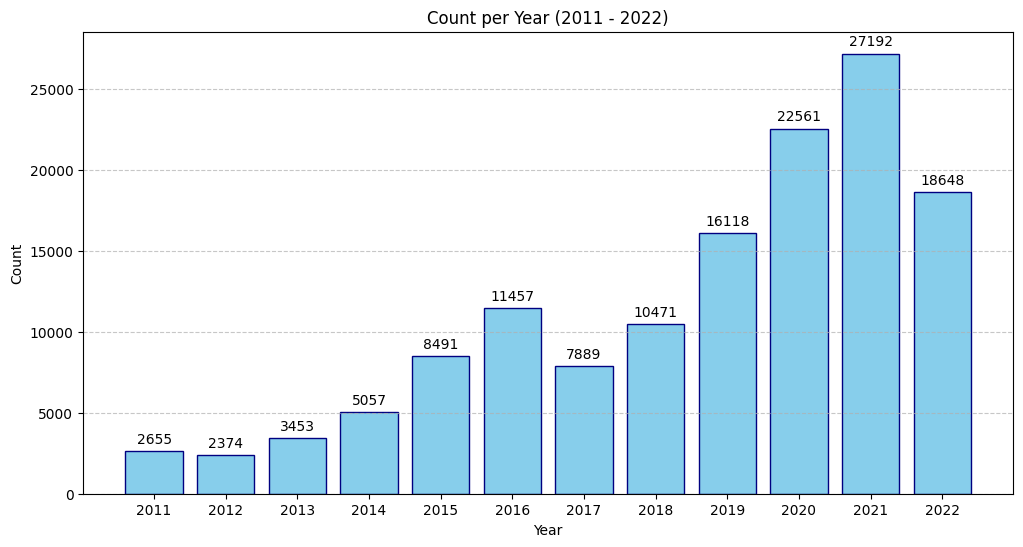

In [ ]:
import matplotlib.pyplot as plt

# Data extracted from the image
years = [
    '2011', '2012', '2013', '2014', '2015', '2016',
    '2017', '2018', '2019', '2020', '2021', '2022'
]
values = [
    2655, 2374, 3453, 5057, 8491, 11457,
    7889, 10471, 16118, 22561, 27192, 18648
]

# Creating the histogram (bar chart)
plt.figure(figsize=(12, 6))
bars = plt.bar(years, values, color='skyblue', edgecolor='navy')

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Count per Year (2011 - 2022)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding values above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 300, yval, ha='center', va='bottom')

plt.show()


# Lemmatization

In [ ]:
# Direct and forced installation from the official SpaCy repository
!pip install https://github.com/explosion/spacy-models/releases/download/it_core_news_lg-3.8.0/it_core_news_lg-3.8.0-py3-none-any.whl

import it_core_news_lg
import pandas as pd
import re
from tqdm import tqdm

# Load the balanced dataset
file_path = '/content/drive/MyDrive/IRMA/final_master_dataset.parquet'
df = pd.read_parquet(file_path)
print(f"Dataset loaded: {len(df)} total articles.")

# Import and configure SpaCy
print("Loading linguistic model...")
nlp = it_core_news_lg.load(disable=['ner', 'parser'])

# Vectorized Regex Cleaning
print("Cleaning Regex (URL and punctuation)...")
df['text_clean'] = df['input_text'].astype(str).str.lower()
df['text_clean'] = df['text_clean'].str.replace(r'http\S+|www\S+', '', regex=True)
df['text_clean'] = df['text_clean'].str.replace(r'[^a-zàèéìòù\s]', ' ', regex=True)


# Batch SpaCy Processing
print("SpaCy Elaboration in batch...")
clean_texts = []

# Using nlp.pipe for highly optimized batch processing
docs = nlp.pipe(df['text_clean'], batch_size=500)

for doc in tqdm(docs, total=len(df), desc="Lemmatization in progress"):
    tokens = [token.lemma_ for token in doc
              if not token.is_stop and not token.is_space and len(token.text) > 2]
    clean_texts.append(' '.join(tokens))

# DataFrame update and cleaning empty strings
df['text_clean'] = clean_texts
df = df[df['text_clean'].str.strip().astype(bool)].reset_index(drop=True)

# Final save
output_path = '/content/drive/MyDrive/IRMA/clean_final_master_dataset.parquet'
df.to_parquet(output_path)
print(f"\nPreprocessing completed and saved to {output_path}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.9/567.9 MB 2.6 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: 256732 total articles.
Loading linguistic model...
Cleaning Regex (URL and punctuation)...
SpaCy Elaboration in batch...


Lemmatization in progress: 100%|██████████| 256732/256732 [2:31:25<00:00, 28.26it/s]



Preprocessing completed and saved to /content/drive/MyDrive/IRMA/clean_final_master_dataset.parquet


# SVM Comparison (TF-IDF vs BoW)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tqdm import tqdm

# Load the clean dataset
file_path = '/content/drive/MyDrive/IRMA/clean_final_master_dataset.parquet'
df = pd.read_parquet(file_path)
X = df['text_clean']
y = df['label']

# Feature extraction
print("Feature extraction (TF-IDF)...")
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

print("Feature extraction (BoW)...")
bow = CountVectorizer(max_features=50000, ngram_range=(1,2))
X_bow = bow.fit_transform(X)

# Cross-Validation Setup
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

# SVM training
for feat_name, X_feat in [('TF-IDF', X_tfidf), ('BoW', X_bow)]:
    print(f"\nTraining started: SVM + {feat_name}")
    fold_scores = []

    folds = list(skf.split(X_feat, y))
    clf = LinearSVC(max_iter=2000, dual=False)

    for fold_idx, (train_index, test_index) in enumerate(tqdm(folds, desc=f"SVM ({feat_name})", unit="fold")):
        X_tr, X_te = X_feat[train_index], X_feat[test_index]
        y_tr, y_te = y.iloc[train_index], y.iloc[test_index]

        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        fold_scores.append(f1_score(y_te, y_pred, average='macro'))

    results[f"SVM + {feat_name}"] = f"{np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}"
    print(f"SVM + {feat_name} Completed\nF1-Macro = {results[f'SVM + {feat_name}']}")

print("\nFinal results:")
for nome, score in results.items():
    print(f"- {nome}: {score}")

Feature extraction (TF-IDF)...
Feature extraction (BoW)...

Training started: SVM + TF-IDF


SVM (TF-IDF): 100%|██████████| 10/10 [04:42<00:00, 28.29s/fold]


SVM + TF-IDF Completed
F1-Macro = 0.9327 ± 0.0016

Training started: SVM + BoW


SVM (BoW): 100%|██████████| 10/10 [1:55:30<00:00, 693.01s/fold]

SVM + BoW Completed
F1-Macro = 0.9142 ± 0.0020

Final results:
- SVM + TF-IDF: 0.9327 ± 0.0016
- SVM + BoW: 0.9142 ± 0.0020


Fast training of SVM model...


/tmp/ipykernel_53184/2868934919.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weights_fake, y=fake_words, ax=axes[0], palette="Reds_r")
/tmp/ipykernel_53184/2868934919.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.abs(weights_real), y=real_words, ax=axes[1], palette="Greens_r")



Graph generated and saved successfully in: /content/drive/MyDrive/IRMA/feature_importance_svm.png


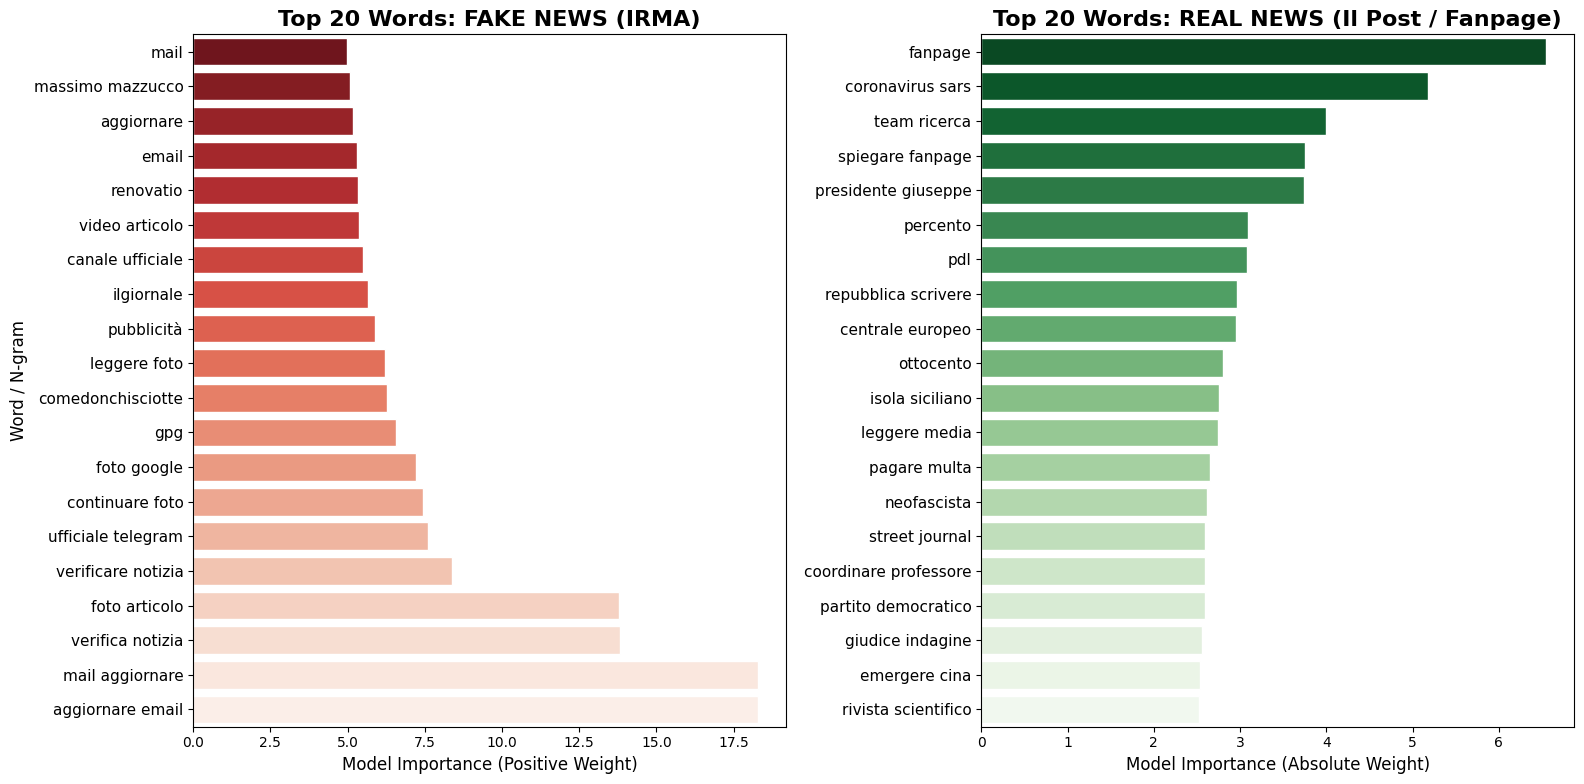

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.svm import LinearSVC

# Train a fast SVM model on the entire dataset
# (Uses X_tfidf and y already calculated in the previous cell)
print("Fast training of SVM model...")
svm_clf = LinearSVC(max_iter=2000, dual=False)
svm_clf.fit(X_tfidf, y)

# Extract feature names (words) from TF-IDF and weights from SVM
feature_names = tfidf.get_feature_names_out()
weights = svm_clf.coef_[0]

# Select Top 20 words for "Fake" and Top 20 for "Real"
top_fake_idx = np.argsort(weights)[-20:]  # The last 20 (highest positive weights)
top_real_idx = np.argsort(weights)[:20]   # The first 20 (lowest negative weights)

fake_words = [feature_names[i] for i in top_fake_idx]
weights_fake = [weights[i] for i in top_fake_idx]

real_words = [feature_names[i] for i in top_real_idx]
weights_real = [weights[i] for i in top_real_idx]

# Creation of the double graphic layout
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.set_theme(style="whitegrid")

# --- Left chart: FAKE NEWS ---
sns.barplot(x=weights_fake, y=fake_words, ax=axes[0], palette="Reds_r")
axes[0].set_title("Top 20 Words: FAKE NEWS (IRMA)", fontsize=16, weight='bold')
axes[0].set_xlabel("Model Importance (Positive Weight)", fontsize=12)
axes[0].set_ylabel("Word / N-gram", fontsize=12)
axes[0].tick_params(axis='y', labelsize=11)

# --- Right chart: REAL NEWS ---
# Use absolute value (np.abs) just to make the green bar point right
sns.barplot(x=np.abs(weights_real), y=real_words, ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 20 Words: REAL NEWS (Il Post / Fanpage)", fontsize=16, weight='bold')
axes[1].set_xlabel("Model Importance (Absolute Weight)", fontsize=12)
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', labelsize=11)

plt.tight_layout()

# Save the image on Drive
path = '/content/drive/MyDrive/IRMA/feature_importance_svm.png'
plt.savefig(path, dpi=300, bbox_inches='tight')

print(f"\nGraph generated and saved successfully in: {path}")

# Neural Networks (CNN and LSTM) with FastText

In [ ]:
# Download Italian FastText Word Embeddings
print("Downloading FastText vectors...")
!wget --show-progress -O /content/ita_embeddings.vec.gz "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.it.300.vec.gz"
!gunzip -f /content/ita_embeddings.vec.gz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, LSTM, Bidirectional, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
import time

# Load dataset
file_path = '/content/drive/MyDrive/IRMA/clean_final_master_dataset.parquet'
df = pd.read_parquet(file_path)
print(f"Dataset loaded: {len(df)} articles.")

# Network parameters
MAX_WORDS = 60000  # Maximum vocabulary
MAX_LEN   = 256    # Maximum number of words per article
EMBED_DIM = 300    # FastText dimensions

# Sequence preparation (Tokenization for Keras)
print("\nText tokenization...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_clean'])
sequences = tokenizer.texts_to_sequences(df['text_clean'])
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y_arr = np.array(df['label'])

# Creation of Embedding Matrix with FastText
print("Creating the Vector Embedding Matrix...")
word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBED_DIM))

with open('/content/ita_embeddings.vec', encoding='utf-8') as f:
    for i, line in enumerate(f):
        # Skip the first line because FastText has an info header
        if i == 0 and len(line.split()) == 2:
            continue

        parts = line.split()
        word = parts[0]

        # Safety filter for words existing in our dictionary
        if word in word_index and word_index[word] < MAX_WORDS:
            # Ensure the dimension is exactly 300
            if len(parts[1:]) == EMBED_DIM:
                embedding_matrix[word_index[word]] = np.array(parts[1:], dtype='float32')

# Data Split (90% Train, 10% Test)
X_tr, X_te, y_tr, y_te = train_test_split(X_seq, y_arr, test_size=0.1, stratify=y_arr, random_state=42)

# Early Stopping configuration to prevent Overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

# ==========================================
# MODEL 1: CNN (Convolutional Neural Network)
# ==========================================
print("\nCNN training started...")
cnn = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, weights=[embedding_matrix], trainable=False),
    SpatialDropout1D(0.2),
    Conv1D(64, 5, activation='relu', kernel_regularizer=l2(0.001)),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_cnn = cnn.fit(X_tr, y_tr, epochs=10, batch_size=128, validation_data=(X_te, y_te), callbacks=[early_stop])
print(f"CNN trained in {(time.time() - start_time)/60:.2f} minutes.")

# ==========================================
# MODEL 2: Bi-LSTM (Bidirectional Long Short-Term Memory)
# ==========================================
print("\nLSTM training started...")
lstm = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, weights=[embedding_matrix], trainable=False),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_lstm = lstm.fit(X_tr, y_tr, epochs=10, batch_size=128, validation_data=(X_te, y_te), callbacks=[early_stop])
print(f"LSTM trained in {(time.time() - start_time)/60:.2f} minutes.")

--2026-06-10 16:18:54--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.it.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.52, 65.9.168.62, 65.9.168.4, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1272825284 (1.2G) [binary/octet-stream]
Saving to: ‘/content/ita_embeddings.vec.gz’

/content/ita_embedd 100%[===================>]   1.18G  92.2MB/s    in 11s     

2026-06-10 16:19:05 (113 MB/s) - ‘/content/ita_embeddings.vec.gz’ saved [1272825284/1272825284]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: 256728 articles.

Text tokenization...
Creating the Vector Embedding Matrix...

CNN training started...
Epoch 1/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8440 - loss: 0.4270 - val_accuracy: 0.8718 - val_loss: 0.3623
Epoch 2/1

Epoch 1/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 78s 38ms/step - accuracy: 0.8572 - loss: 0.3249 - val_accuracy: 0.8739 - val_loss: 0.2880
Epoch 2/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 67s 37ms/step - accuracy: 0.8779 - loss: 0.2794 - val_accuracy: 0.8835 - val_loss: 0.2619
Epoch 3/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 67s 37ms/step - accuracy: 0.8875 - loss: 0.2586 - val_accuracy: 0.8833 - val_loss: 0.2853
Epoch 4/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 66s 37ms/step - accuracy: 0.8984 - loss: 0.2371 - val_accuracy: 0.9005 - val_loss: 0.2286
Epoch 5/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 66s 37ms/step - accuracy: 0.9062 - loss: 0.2208 - val_accuracy: 0.9032 - val_loss: 0.2311
Epoch 6/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9134 - loss: 0.2057 - val_accuracy: 0.9123 - val_loss: 0.2053
Epoch 7/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 66s 37ms/step - accuracy: 0.9183 - loss: 0.1946 - val_accuracy: 0.9165 - val_loss: 0.1993
Epoch 8/10
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 65s 36ms/step - accuracy: 0.9223 -

Graphs generated and saved successfully in: /content/drive/MyDrive/IRMA/learning_curves_deep_learning.png


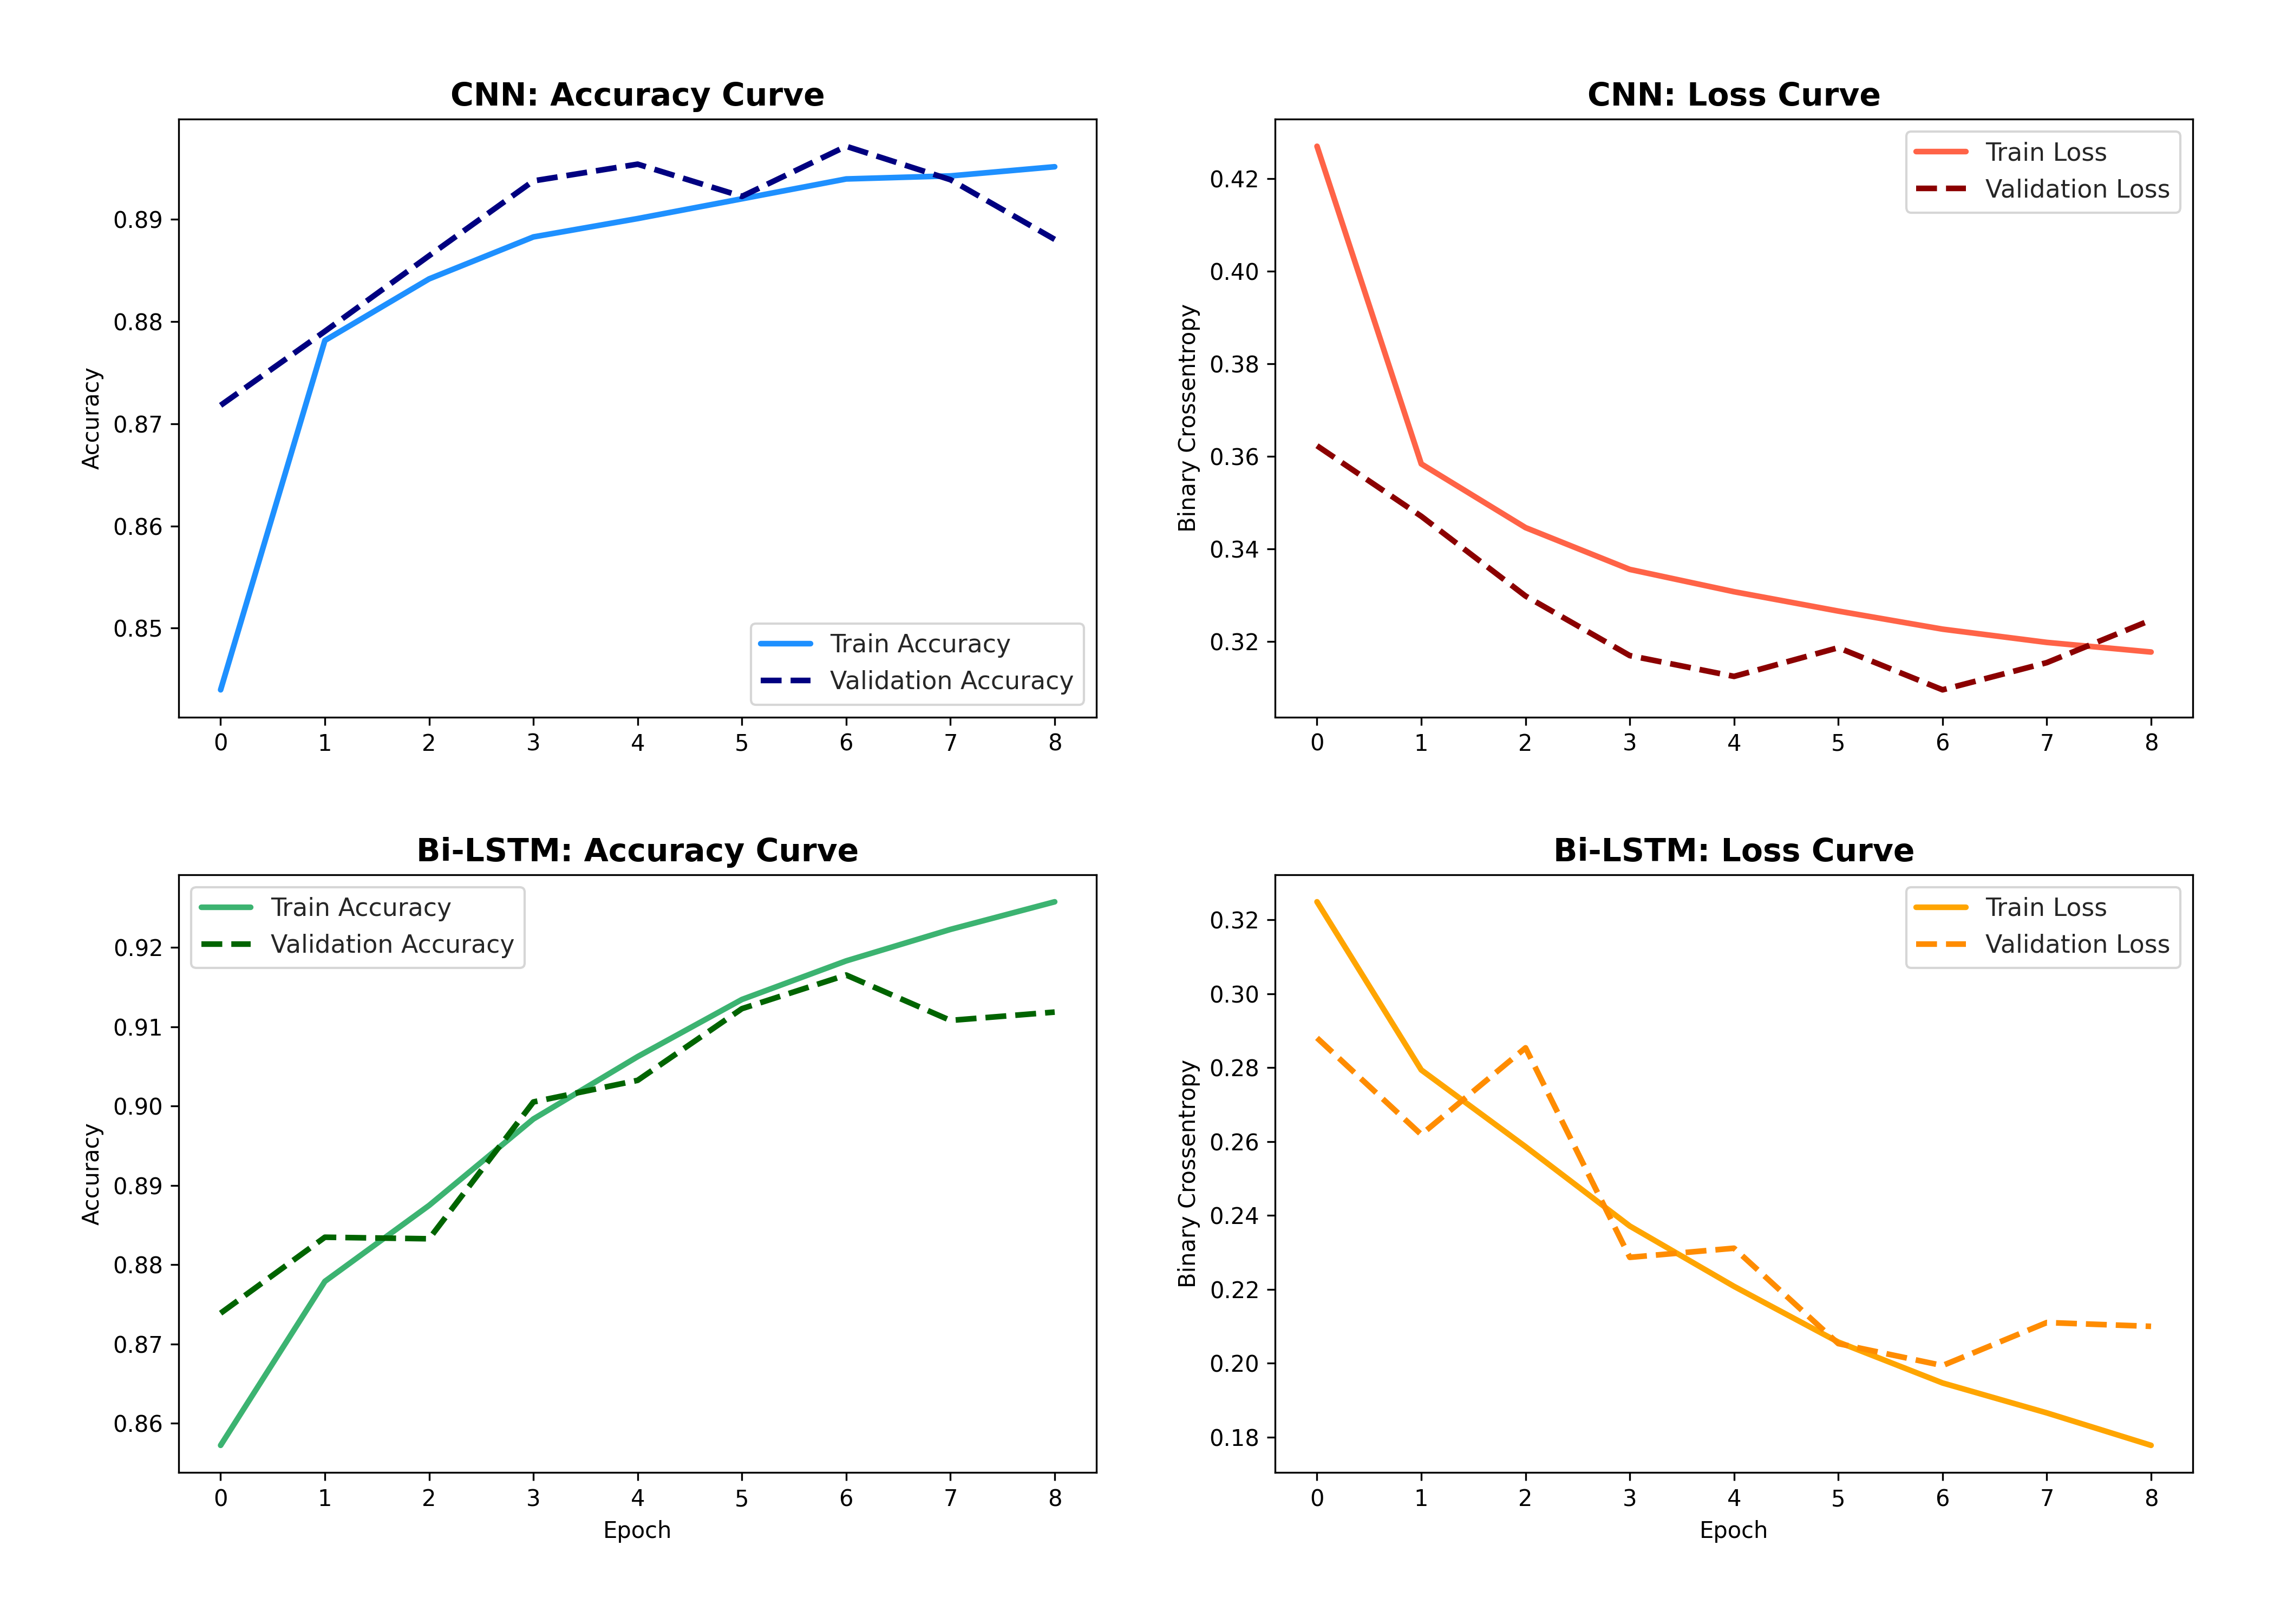

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 layout: First row CNN, Second row LSTM
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# ==============================
# ROW 1: CNN
# ==============================
# Chart 1: CNN Accuracy
axes[0, 0].plot(history_cnn.history['accuracy'], label='Train Accuracy', linewidth=2.5, color='dodgerblue')
axes[0, 0].plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, linestyle='--', color='navy')
axes[0, 0].set_title('CNN: Accuracy Curve', fontsize=14, weight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Chart 2: CNN Loss
axes[0, 1].plot(history_cnn.history['loss'], label='Train Loss', linewidth=2.5, color='tomato')
axes[0, 1].plot(history_cnn.history['val_loss'], label='Validation Loss', linewidth=2.5, linestyle='--', color='darkred')
axes[0, 1].set_title('CNN: Loss Curve', fontsize=14, weight='bold')
axes[0, 1].set_ylabel('Binary Crossentropy')
axes[0, 1].legend()

# ==============================
# ROW 2: LSTM
# ==============================
# Chart 3: LSTM Accuracy
axes[1, 0].plot(history_lstm.history['accuracy'], label='Train Accuracy', linewidth=2.5, color='mediumseagreen')
axes[1, 0].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, linestyle='--', color='darkgreen')
axes[1, 0].set_title('Bi-LSTM: Accuracy Curve', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()

# Chart 4: LSTM Loss
axes[1, 1].plot(history_lstm.history['loss'], label='Train Loss', linewidth=2.5, color='orange')
axes[1, 1].plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2.5, linestyle='--', color='darkorange')
axes[1, 1].set_title('Bi-LSTM: Loss Curve', fontsize=14, weight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Binary Crossentropy')
axes[1, 1].legend()

# Space optimization and saving
plt.tight_layout(pad=3.0)
path = '/content/drive/MyDrive/IRMA/learning_curves_deep_learning.png'
plt.savefig(path, dpi=300)

print(f"Graphs generated and saved successfully in: {path}")
plt.show()

# Italian BERT

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn torch
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original RAW dataset
file_path = '/content/drive/MyDrive/IRMA/final_master_dataset.parquet'
df = pd.read_parquet(file_path)
print(f"Raw dataset loaded: {len(df)} articles.")

# Clean null values
df = df.dropna(subset=['input_text'])
df = df[df['input_text'].str.strip() != ''].reset_index(drop=True)

# Tokenizer initialization
MODEL_NAME = "dbmdz/bert-base-italian-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Data preparation (Cut to 256 tokens)
def tokenize_function(examples):
    return tokenizer(examples['input_text'], truncation=True, padding='max_length', max_length=256)

# Split 90/10
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    df['input_text'].astype(str).tolist(), df['label'].tolist(),
    test_size=0.1, stratify=df['label'].tolist(), random_state=42
)

print("Tokenization with BERT...")
train_dataset = Dataset.from_dict({'input_text': X_tr_raw, 'label': y_tr_raw})
test_dataset = Dataset.from_dict({'input_text': X_te_raw, 'label': y_te_raw})

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Model Initialization
print("Loading pre-trained BERT model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Trainer Configuration
args = TrainingArguments(
    output_dir                  = '/content/drive/MyDrive/IRMA/bert_results',
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 32,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    fp16                        = True,
    logging_steps               = 500,
    learning_rate               = 2e-5,
    warmup_steps                = 500,
    weight_decay                = 0.01
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='macro')
    }

# Recreate the Trainer to reset previous corrupted progress
trainer = Trainer(
    model           = model,
    args            = args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
)

# Training
print("\nBERT Fine-Tuning started...")
trainer.train()

Raw dataset loaded: 256732 articles.


Tokenization with BERT...


Loading pre-trained BERT model...


[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-italian-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT Fine-Tuning started...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.074212,0.119734,0.976124,0.976117
2,0.040345,0.090826,0.983174,0.983173
3,0.012587,0.121290,0.983290,0.983289


TrainOutput(global_step=86649, training_loss=0.05742824466537016, metrics={'train_runtime': 10632.5857, 'train_samples_per_second': 65.193, 'train_steps_per_second': 8.149, 'total_flos': 9.119087134405632e+16, 'train_loss': 0.05742824466537016, 'epoch': 3.0})

Extracting predictions from the BERT model on the test set...



CLASSIFICATION REPORT (Italian BERT) 
               precision    recall  f1-score   support

Real News (0)     0.9740    0.9931    0.9835     12837
Fake News (1)     0.9929    0.9735    0.9831     12837

     accuracy                         0.9833     25674
    macro avg     0.9835    0.9833    0.9833     25674
 weighted avg     0.9835    0.9833    0.9833     25674


Confusion matrix saved in: /content/drive/MyDrive/IRMA/confusion_matrix_bert.png


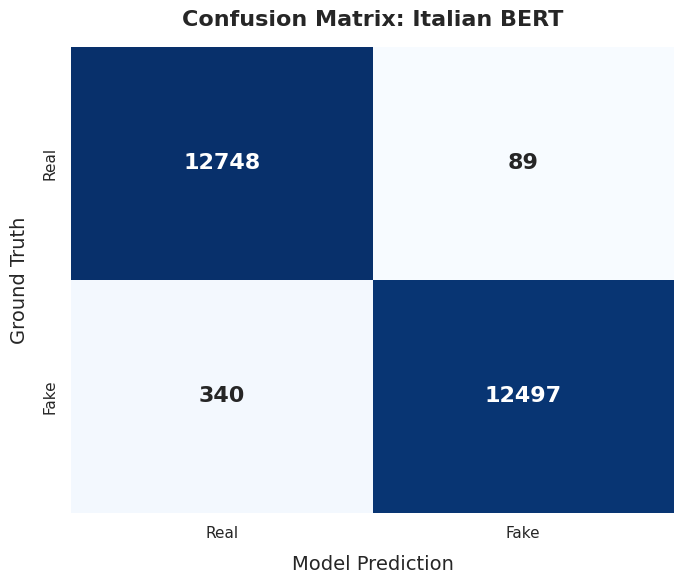

In [ ]:
# --- BERT EVALUATION AND CONFUSION MATRIX ---

print("Extracting predictions from the BERT model on the test set...")
preds = trainer.predict(test_dataset)
y_pred_bert = np.argmax(preds.predictions, axis=-1)
y_true_bert = preds.label_ids

# Print the Report
print("\nCLASSIFICATION REPORT (Italian BERT) ")
print(classification_report(y_true_bert, y_pred_bert, target_names=['Real News (0)', 'Fake News (1)'], digits=4))

# Generation of the Graphic Confusion Matrix
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(7, 6))
sns.set_theme(style="white")
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'],
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Confusion Matrix: Italian BERT', fontsize=16, weight='bold', pad=15)
plt.xlabel('Model Prediction', fontsize=14, labelpad=10)
plt.ylabel('Ground Truth', fontsize=14, labelpad=10)

# Saving
path = '/content/drive/MyDrive/IRMA/confusion_matrix_bert.png'
plt.tight_layout()
plt.savefig(path, dpi=300)
print(f"\nConfusion matrix saved in: {path}")

# News Samples from Dataset

In [ ]:
import pandas as pd

# Ensure the dataset is loaded
file_path = '/content/drive/MyDrive/IRMA/final_balanced_dataset.parquet'
df = pd.read_parquet(file_path)

# Set the number of articles to read
n_articles = 2

# True news extraction
print("   TRUE NEWS EXAMPLES (Il Post / Fanpage)\n")

# Use .sample() without random_state so it changes every time the cell is executed
real_samples = df[df['label'] == 0].sample(n_articles)

for i, testo in enumerate(real_samples['text']):
    print(f"--- TRUE #{i+1} ---")
    # Print the first 800 characters
    print(str(testo)[:800] + " [...continue]\n")

# Fake news extraction
print("   FAKE NEWS EXAMPLES (Dataset IRMA)\n")

fake_samples = df[df['label'] == 1].sample(n_articles)

for i, testo in enumerate(fake_samples['text']):
    print(f"--- FAKE #{i+1} ---")
    print(str(testo)[:800] + " [...continue]\n")

   TRUE NEWS EXAMPLES (Il Post / Fanpage)

--- TRUE #1 ---
Quest’estate un problema serio colpisce l’agricoltura italiana: la produzione dei pomodori – e soprattutto il trasporto dai luoghi di raccolta a quelli di lavorazione – non sta andando bene. Le ragioni sono numerose. Anzitutto il clima, che è stato estremo negli scorsi mesi e che secondo la CIA, Confederazione italiana agricoltori, ha causato «uno shock termico-idrico». Inoltre manca la manodopera nei campi ed è in crisi il settore logistico: c’è carenza di autotrasportatori che spostino il raccolto dai campi fino ai luoghi di trasformazione industriale. Le regioni Puglia, Campania, Molise e Basilicata hanno scritto al ministro dell’Agricoltura Stefano Patuanelli chiedendo interventi urgenti e indennizzi immediati. In Campania i danni riguardano il 20 per cento della produzione con milioni [...continue]

--- TRUE #2 ---
Rockstar di Sfera Ebbasta è l'album più venduto del 2018, confermando la tendenza già evidente quando a metà 